# KAN-Assisted Tomography — MOESM4
### KAN (train/val/test + overfitting check) vs. two SDP reconstructions: **recursive** (paper-faithful) and **joint**

**Data:** `MOESM4` — second APD configuration from Zhang et al., *Mapping coherence in measurement via full quantum tomography of a hybrid optical detector*, Nature Photonics 6, 364 (2012), Fig. 2b.

This notebook contains three reconstructions of the same detector, all evaluated on one shared held-out test set:

1. **KAN** — learns $(|\alpha|^2,\theta)\to p(\text{1-click})$ directly. Trained with a **60/20/20** train/validation/test split: the validation set monitors overfitting and selects the grid-refinement stage; the test set is the final number.

2. **Recursive SDP** — the paper's *literal* algorithm: phase-average the statistics to isolate each diagonal, reconstruct $l=0$ (diagonal), then each off-diagonal $l=1,2,\dots$ on top, enforcing positivity of the growing matrix at every step.

3. **Joint SDP** — all bands reconstructed in one semi-definite program under a single PSD constraint (computationally heavier per solve, but more accurate on small problems).

> **Why two SDPs?** The recursion is the paper's key contribution — it drops the cost from quadratic to linear per step, which is what makes their 1.8-million-parameter PNRD tractable. But on a *small* APD, the joint solve fits better because it uses the full 2-D statistics at once rather than phase-averaged slices. Showing both quantifies the **accuracy ↔ tractability tradeoff**.

> **Note on splits.** The SDP reconstructs a *physical operator* and cannot overfit, so it uses the **full** dataset (the paper does too). Only the KAN — a learned model — needs train/val/test. For a fair comparison, both SDPs are *scored* on the KAN's held-out test rows via the Born rule.

---


## 0 · Setup

In [1]:
# !pip install pykan torch cvxpy xlrd scipy scikit-learn matplotlib
import numpy as np, torch, time
import matplotlib.pyplot as plt
from scipy.special import gammaln
from sklearn.model_selection import train_test_split
torch.set_default_dtype(torch.float64)
np.random.seed(0); torch.manual_seed(0)
print("imports OK")

imports OK


In [2]:
DATA_DIR = "data"   # <-- folder holding the .xls files
FILE = f"{DATA_DIR}/41566_2012_BFnphoton2012107_MOESM4_ESM.xls"


## 1 · Load MOESM4

Columns: $|\alpha|^2$, $\theta$, #0-click, #1-click. Input $X=(|\alpha|^2,\theta)$; label $y=p_{\text{1-click}}=\#1\text{-click}/(\#0\text{-click}+\#1\text{-click})$.


In [3]:
import xlrd
sh = xlrd.open_workbook(FILE).sheet_by_index(0)
rows = np.array([sh.row_values(r) for r in range(1, sh.nrows)])
a2, theta, c0, c1 = rows[:,0], rows[:,1], rows[:,2], rows[:,3]
X = np.column_stack([a2, theta]); y = c1/(c0+c1)
print("rows:", len(X), "| |a|^2 %.3f..%.1f | theta %.2f..%.2f | p1 %.3f..%.3f"
      % (a2.min(), a2.max(), theta.min(), theta.max(), y.min(), y.max()))

rows: 3720 | |a|^2 0.178..38.5 | theta 0.01..6.28 | p1 0.001..0.997


### 1.1 · Response surface

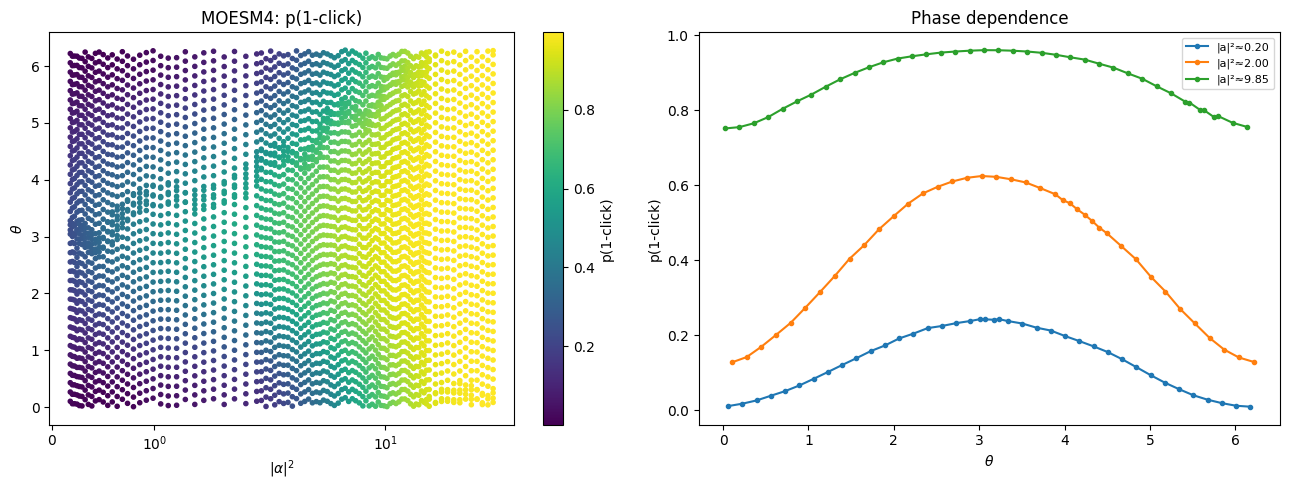

In [4]:
fig, ax = plt.subplots(1,2, figsize=(13,5))
sc = ax[0].scatter(a2, theta, c=y, s=9, cmap="viridis")
ax[0].set_xlabel(r"$|\alpha|^2$"); ax[0].set_ylabel(r"$\theta$"); ax[0].set_xscale("symlog")
ax[0].set_title("MOESM4: p(1-click)"); plt.colorbar(sc, ax=ax[0], label="p(1-click)")
for v in [0.2, 2.0, 10.0]:
    val = a2[np.argmin(np.abs(a2-v))]; m = np.isclose(a2,val,atol=1e-2); o=np.argsort(theta[m])
    ax[1].plot(theta[m][o], y[m][o], marker=".", label=f"|a|²≈{val:.2f}")
ax[1].set_xlabel(r"$\theta$"); ax[1].set_ylabel("p(1-click)")
ax[1].set_title("Phase dependence"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2 · Split — 60/20/20 (for the KAN)

The SDPs ignore this and use the full data; both are later scored on `Xte`.


In [5]:
X_tmp, Xte, y_tmp, yte = train_test_split(X, y, test_size=0.20, random_state=42)
Xtr, Xva, ytr, yva = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)  # 0.25*0.8=0.20
print("train:", len(Xtr), " val:", len(Xva), " test:", len(Xte))

train: 2232  val: 744  test: 744


## 3 · KAN

### 3.1 · Inputs
`log(1 + |α|²)` then normalise to $[-1,1]$ using **train** statistics only. Architecture `[2,3,1]` (a single hidden node can't represent the brightness-dependent fringe). Sigmoid output keeps $p_1\in[0,1]$.


In [6]:
from kan import KAN
prep = lambda Xr: np.column_stack([np.log1p(Xr[:,0]), Xr[:,1]])
MN, MX = prep(Xtr).min(0), prep(Xtr).max(0)
norm = lambda Xr: 2*(prep(Xr)-MN)/(MX-MN)-1
dataset = {"train_input":torch.tensor(norm(Xtr)),"train_label":torch.tensor(ytr.reshape(-1,1)),
           "test_input": torch.tensor(norm(Xva)),"test_label": torch.tensor(yva.reshape(-1,1))}  # monitoring=VALIDATION
sig_mse = lambda p,t: torch.mean((torch.sigmoid(p)-t)**2)
def predict(m,Xr):
    with torch.no_grad(): return torch.sigmoid(m(torch.tensor(norm(Xr)))).numpy().ravel()
def rms(m,Xr,yt): return float(np.sqrt(np.mean((predict(m,Xr)-yt)**2)))
print("KAN data prepared (pykan 'test_*' slot holds the VALIDATION set)")

KAN data prepared (pykan 'test_*' slot holds the VALIDATION set)


### 3.2 · Baseline + overfitting check
`pykan.fit` logs train and monitoring (validation) loss each step. If validation turns up while train keeps falling → overfitting.


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.31e-03 | test_loss: 3.26e-03 | reg: 2.05e+01 | : 100%|█| 150/150 [00:12<00:00, 12.29


saving model version 0.1


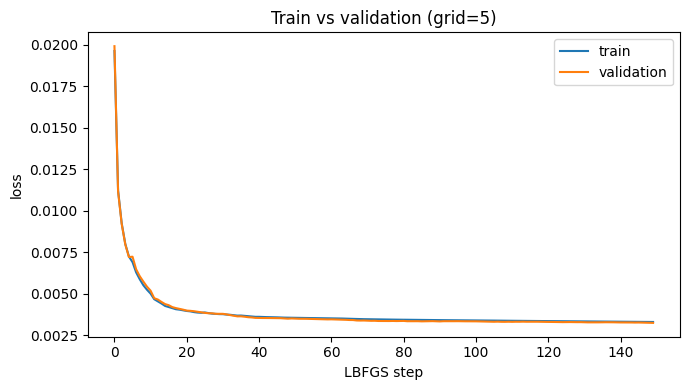

grid=5  train 0.00331 | val 0.00326 | test 0.00352


In [7]:
model = KAN(width=[2,3,1], grid=5, k=3, seed=0)
res = model.fit(dataset, opt="LBFGS", steps=150, loss_fn=sig_mse)
plt.figure(figsize=(7,4))
plt.plot(res['train_loss'], label="train"); plt.plot(res['test_loss'], label="validation")
plt.xlabel("LBFGS step"); plt.ylabel("loss"); plt.title("Train vs validation (grid=5)")
plt.legend(); plt.tight_layout(); plt.show()
print("grid=5  train %.5f | val %.5f | test %.5f" % (rms(model,Xtr,ytr),rms(model,Xva,yva),rms(model,Xte,yte)))

### 3.3 · Tuning by grid refinement, validation-selected
Refine 5→10→20; record train/val/test at each stage; pick the grid where **validation** RMS bottoms out.


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.31e-03 | test_loss: 3.26e-03 | reg: 2.05e+01 | : 100%|█| 150/150 [00:11<00:00, 12.65


saving model version 0.1
saving model version 0.2


| train_loss: 3.10e-03 | test_loss: 3.08e-03 | reg: 2.08e+01 | : 100%|█| 80/80 [00:06<00:00, 12.05it


saving model version 0.3
grid=10  train 0.00310 | val 0.00308 | test 0.00333 | [7s]
saving model version 0.4


| train_loss: 2.94e-03 | test_loss: 3.07e-03 | reg: 2.08e+01 | : 100%|█| 80/80 [00:07<00:00, 10.50it

saving model version 0.5
grid=20  train 0.00294 | val 0.00307 | test 0.00334 | [8s]


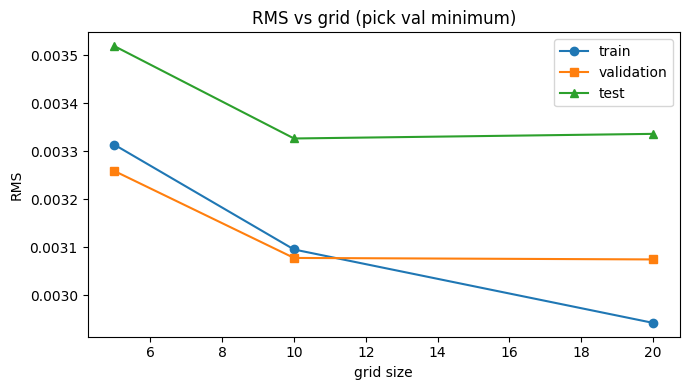

best grid by validation (smallest within 1%): 10


In [8]:
stages=[5,10,20]; hist=[]
model=KAN(width=[2,3,1],grid=5,k=3,seed=0); model.fit(dataset,opt="LBFGS",steps=150,loss_fn=sig_mse)
hist.append((5,rms(model,Xtr,ytr),rms(model,Xva,yva),rms(model,Xte,yte)))
for g in stages[1:]:
    t=time.time(); model=model.refine(g); model.fit(dataset,opt="LBFGS",steps=80,loss_fn=sig_mse)
    hist.append((g,rms(model,Xtr,ytr),rms(model,Xva,yva),rms(model,Xte,yte)))
    print("grid=%-3d train %.5f | val %.5f | test %.5f | [%.0fs]"%(hist[-1]+(time.time()-t,)))
H=np.array(hist)
plt.figure(figsize=(7,4))
plt.plot(H[:,0],H[:,1],'o-',label="train"); plt.plot(H[:,0],H[:,2],'s-',label="validation"); plt.plot(H[:,0],H[:,3],'^-',label="test")
plt.xlabel("grid size"); plt.ylabel("RMS"); plt.title("RMS vs grid (pick val minimum)"); plt.legend(); plt.tight_layout(); plt.show()
# Smallest-within-noise (1-SE-style) rule: choose the SMALLEST grid whose val RMS is within 1% of the
# best. Plain argmin picks grid 20 on a <0.3% val gap vs grid 10 -- i.e. the more-overfit model, on noise.
best_g=int(H[H[:,2] <= H[:,2].min()*1.01, 0].min()); print("best grid by validation (smallest within 1%):", best_g)

In [9]:
# rebuild final KAN refined up to best_g
model=KAN(width=[2,3,1],grid=5,k=3,seed=0); model.fit(dataset,opt="LBFGS",steps=150,loss_fn=sig_mse)
g=5
while g<best_g:
    g=min(g*2,best_g); model=model.refine(g); model.fit(dataset,opt="LBFGS",steps=80,loss_fn=sig_mse)
p_te_kan=predict(model,Xte); rms_kan=rms(model,Xte,yte)
print("FINAL KAN grid=%d | val %.5f | test %.5f"%(g,rms(model,Xva,yva),rms_kan))

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.31e-03 | test_loss: 3.26e-03 | reg: 2.05e+01 | : 100%|█| 150/150 [00:11<00:00, 12.78


saving model version 0.1
saving model version 0.2


| train_loss: 3.09e-03 | test_loss: 3.08e-03 | reg: 2.08e+01 | : 100%|█| 80/80 [00:06<00:00, 12.12it

saving model version 0.3
FINAL KAN grid=10 | val 0.00308 | test 0.00333


### 3.4 · Final KAN fit (test set)

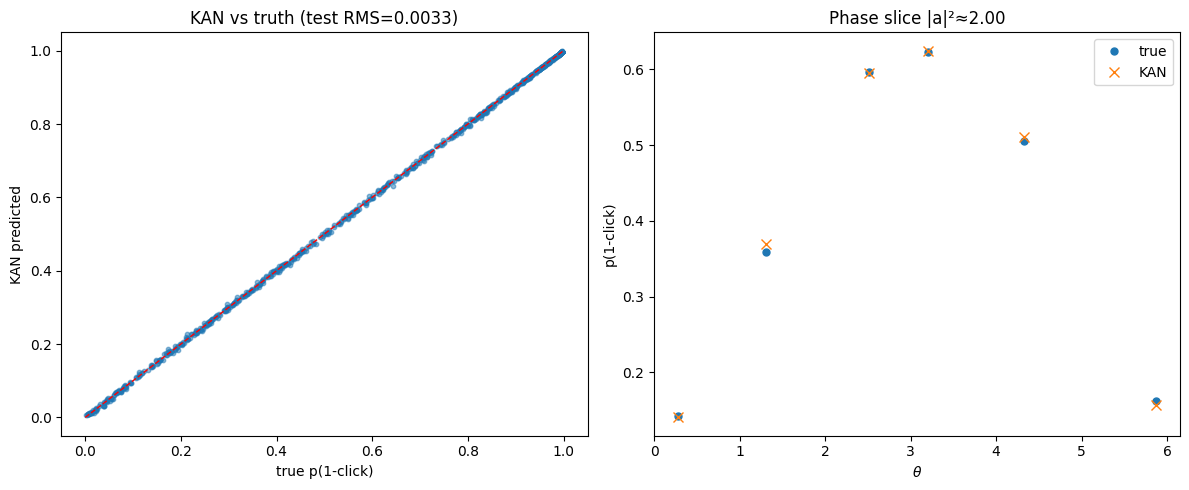

In [10]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].scatter(yte,p_te_kan,s=10,alpha=.5); ax[0].plot([0,1],[0,1],'r--',lw=1)
ax[0].set_xlabel("true p(1-click)"); ax[0].set_ylabel("KAN predicted"); ax[0].set_title(f"KAN vs truth (test RMS={rms_kan:.4f})")
a2te=Xte[:,0]; tgt=a2te[np.argmin(np.abs(a2te-2.0))]; m=np.isclose(a2te,tgt,atol=2e-2); o=np.argsort(Xte[m,1])
ax[1].plot(Xte[m,1][o],yte[m][o],'o',label="true",ms=5); ax[1].plot(Xte[m,1][o],p_te_kan[m][o],'x',label="KAN",ms=7)
ax[1].set_xlabel(r"$\theta$"); ax[1].set_ylabel("p(1-click)"); ax[1].set_title(f"Phase slice |a|²≈{tgt:.2f}"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · SDP reconstructions — shared setup

Both SDPs reconstruct $\hat\Pi_1$ (the 1-click POVM element) from the **full** dataset, then predict the KAN's test rows via the Born rule
$$ p_{\text{1-click}}(\alpha)=\langle\alpha|\hat\Pi_1|\alpha\rangle=\sum_{j,k}e^{-|\alpha|^2}\frac{\alpha^{*j}\alpha^{k}}{\sqrt{j!k!}}(\Pi_1)_{j,k}. $$

**Truncation $d$:** MOESM4 brightness reaches $|\alpha|^2\approx38$, so $d=58$ contains the coherent states with negligible leakage and keeps the full-dimension PSD tractable. **Bands:** $L=4$ leading off-diagonals (paper-faithful; higher bands negligible). **Regulariser:** $\gamma=0.5$.


In [11]:
import cvxpy as cp
D = 58; L = 4; GAMMA = 0.5
logfac = gammaln(np.arange(D+5)+1)

# leakage check
def leakage(mag):
    n=np.arange(D); a2=mag*mag
    return 1 - np.exp(-a2 + n*np.log(a2+1e-300) - gammaln(n+1)).sum()
print("d=%d  max leakage over data: %.2e" % (D, max(leakage(m) for m in np.sqrt(np.unique(np.round(X[:,0],4))))))

d=58  max leakage over data: 2.04e-03


## 4A · Recursive SDP (the paper's literal algorithm)

### 4A.1 · Transformed-Husimi reduced functions
Phase-average the measured probabilities against $e^{-il\theta}$ to isolate each diagonal (paper SI, Eq. 1):
$$ P^{(l)}(|\alpha|) = \frac{1}{2\pi}\int_0^{2\pi} p_{\text{1-click}}(\alpha)\,e^{-il\theta}\,d\theta
   = e^{-|\alpha|^2}\sum_j (\Pi_1)_{j,j+l}\,\frac{|\alpha|^{2j+l}}{\sqrt{(j+l)!\,j!}} . $$
(The $l=0$ average depends only on the diagonal, $l=1$ only on the first off-diagonal, etc. — this is what makes the reconstruction recursive and linear per step. The constant was verified by forward-Born-rule construction: coefficient ratio = 1.0 for all $l$.)

MOESM4 is gridded — every brightness level has 40 phase samples — so the discrete average is accurate.


In [12]:
keys = np.round(X[:,0], 4); phA = X[:,1]; uniq = np.unique(keys)
def reduced_P(l):
    mags = np.array([np.sqrt(k) for k in uniq])
    vals = np.array([np.mean(y[keys==k]*np.exp(-1j*l*phA[keys==k])) for k in uniq])
    return mags, vals
def F_matrix(mags, l):
    F = np.zeros((len(mags), D-l)); a2v = mags**2
    for j in range(D-l):
        F[:, j] = np.exp(-a2v + (2*j+l)*np.log(mags+1e-300) - 0.5*(logfac[j+l]+logfac[j]))
    return F
m0, P0 = reduced_P(0)
print("brightness levels:", len(m0), "| P^(0) imag (should be ~0): %.2e" % np.abs(P0.imag).max())

brightness levels: 93 | P^(0) imag (should be ~0): 0.00e+00


### 4A.2 · Step $l=0$ — diagonal
$\min_d \lVert P^{(0)}-F^{(0)}d\rVert^2+\gamma\sum_j|d_j-d_{j+1}|^2$ s.t. $0\le d_j\le1$ (each diagonal entry is a probability; completeness gives $\Pi_0=I-\Pi_1$).


In [13]:
F0 = F_matrix(m0, 0); d0 = cp.Variable(D)
cp.Problem(cp.Minimize(cp.sum_squares(F0@d0 - P0.real) + GAMMA*cp.sum_squares(d0[1:]-d0[:-1])),
           [d0>=0, d0<=1]).solve(solver=cp.CLARABEL)
diag = np.array(d0.value)
print("l=0 done | diagonal rises %.3f -> %.3f (max %.3f)" % (diag[0], diag[min(40,D-1)], diag.max()))

l=0 done | diagonal rises 0.121 -> 0.998 (max 0.999)


/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: divide by zero encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: overflow encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: invalid value encountered in matmul
  return values[0] @ values[1]


### 4A.3 · Recursive steps $l=1\ldots4$ — add each off-diagonal with **growing-matrix** positivity

For each $l$ we solve for that off-diagonal band, fixing all lower bands, and constrain the **full growing banded matrix** to be a valid POVM element: $M\succeq0$ **and** $I-M\succeq0$ (both floor and ceiling — the ceiling is essential, without it off-diagonals push eigenvalues past 1). This is the rigorous form of the paper's Sylvester-criterion positivity for multiple simultaneous bands.


In [14]:
bands = {0: diag}; I = np.eye(D)
for l in range(1, L+1):
    mL, PL = reduced_P(l); FL = F_matrix(mL, l); n = D-l
    if np.abs(PL.imag).max() > 0.1*np.abs(PL.real).max():       # imag sanity check (previously only done for l=0)
        print("  [warn] l=%d: P^(l) imag NOT negligible (|im|max=%.2e vs |re|max=%.2e) -> real-only fit discards signal"
              % (l, np.abs(PL.imag).max(), np.abs(PL.real).max()))
    x = cp.Variable(n)
    M = cp.diag(cp.Constant(diag))                    # fixed diagonal
    for ll in range(1, l):                            # fixed lower off-diagonals
        bv = bands[ll]; M = M + cp.Constant(np.diag(bv, ll) + np.diag(bv, -ll))
    for j in range(n):                                # variable band l
        S = np.zeros((D, D)); S[j, j+l] = 1; S[j+l, j] = 1; M = M + x[j]*cp.Constant(S)
    # Constraints: POVM positivity only. The earlier `cp.sum(x)==0` was spurious -- an off-diagonal
    # band of a POVM element has no zero-sum constraint; it offset the whole band and inflated the RMS.
    cp.Problem(cp.Minimize(cp.sum_squares(FL@x - PL.real) + GAMMA*cp.sum_squares(x[1:]-x[:-1])),
               [M >> 0, I - M >> 0]).solve(solver=cp.CLARABEL)
    bands[l] = np.array(x.value)
    print("l=%d done | max|off| %.3f" % (l, np.abs(bands[l]).max()))

Pi1_rec = np.diag(diag)
for l in range(1, L+1):
    bv = bands[l]
    for j in range(D-l): Pi1_rec[j, j+l] = bv[j]; Pi1_rec[j+l, j] = bv[j]
ev = np.linalg.eigvalsh(Pi1_rec)
print("\nrecursive Pi1: eig [%.4f, %.4f] valid POVM: %s"
      % (ev.min(), ev.max(), ev.min()>-1e-3 and ev.max()<1+1e-3))

  [warn] l=1: P^(l) imag NOT negligible (|im|max=6.02e-02 vs |re|max=1.45e-01) -> real-only fit discards signal
l=1 done | max|off| 0.166
  [warn] l=2: P^(l) imag NOT negligible (|im|max=5.65e-02 vs |re|max=7.29e-02) -> real-only fit discards signal
l=2 done | max|off| 0.091
  [warn] l=3: P^(l) imag NOT negligible (|im|max=5.42e-02 vs |re|max=6.81e-02) -> real-only fit discards signal
l=3 done | max|off| 0.078
  [warn] l=4: P^(l) imag NOT negligible (|im|max=5.37e-02 vs |re|max=6.26e-02) -> real-only fit discards signal
l=4 done | max|off| 0.026

recursive Pi1: eig [0.0136, 1.0000] valid POVM: True


## 4B · Joint SDP (all bands at once)

Reconstruct all bands $l=0\ldots4$ simultaneously as one Hermitian PSD variable, with the full statistics (not phase-averaged). Same constraints ($0\preceq\Pi_1\preceq I$), same $\gamma$.


In [15]:
alpha = np.sqrt(X[:,0])*np.exp(1j*X[:,1]); ab, ph = np.abs(alpha), np.angle(alpha)
idx = [(j,k) for j in range(D) for k in range(j, min(j+L+1, D))]
Are = np.zeros((len(alpha), len(idx))); Aim = np.zeros((len(alpha), len(idx)))
for c,(j,k) in enumerate(idx):
    C = np.exp(-ab**2 + (j+k)*np.log(ab+1e-300) - 0.5*(logfac[j]+logfac[k]))*np.exp(1j*(k-j)*ph)
    if j==k: Are[:,c] = C.real
    else:    Are[:,c] = 2*C.real; Aim[:,c] = -2*C.imag

Pij = cp.Variable((D,D), hermitian=True); ii = tuple(np.array(idx).T)
pred = Are @ cp.real(Pij[ii]) + Aim @ cp.imag(Pij[ii])
reg = 0
for l in range(L+1):
    de = [Pij[j, j+l] for j in range(D-l)]
    for a,b in zip(de[:-1], de[1:]): reg += cp.square(cp.abs(a-b))
cp.Problem(cp.Minimize(cp.sum_squares(pred - y) + GAMMA*reg),
           [Pij >> 0, np.eye(D) - Pij >> 0]).solve(solver=cp.SCS, max_iters=5000, eps=1e-5)
Pi1_joint = (Pij.value + Pij.value.conj().T)/2
ev = np.linalg.eigvalsh(Pi1_joint)
print("joint Pi1: eig [%.4f, %.4f] valid POVM: %s"
      % (ev.min(), ev.max(), ev.min()>-1e-3 and ev.max()<1+1e-3))

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_1888/3190471506.py:16: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  [Pij >> 0, np.eye(D) - Pij >> 0]).solve(solver=cp.SCS, max_iters=5000, eps=1e-5)


joint Pi1: eig [0.0007, 1.0000] valid POVM: True


## 4C · Structural check (Fig. 2b) — both reconstructions

Rising diagonal (number sensitivity) + negative leading off-diagonal decaying with $j$ (phase sensitivity).


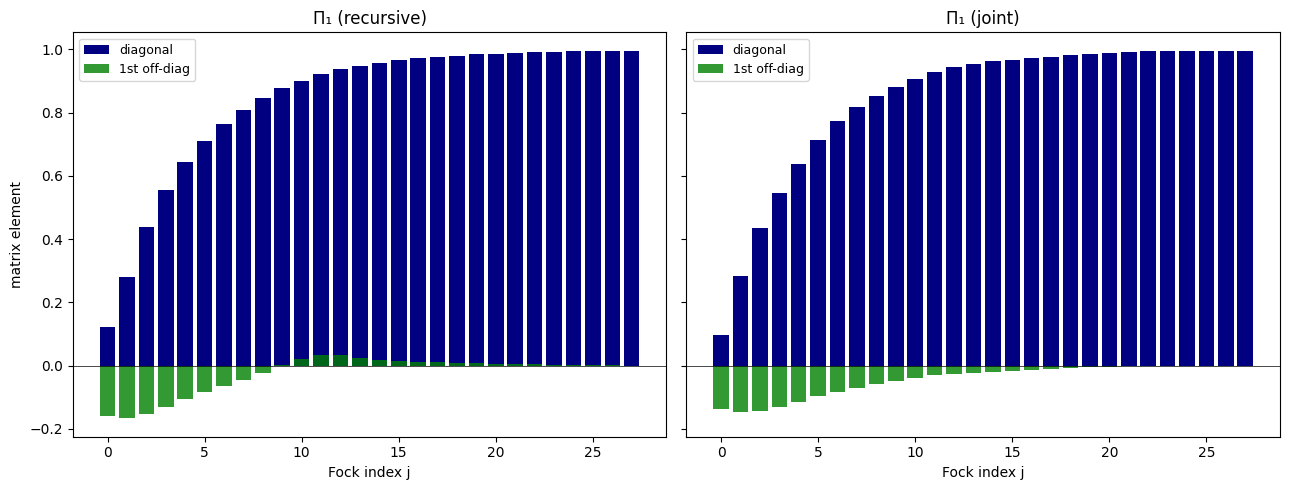

In [16]:
def diag_off(P): return np.real(np.diag(P)), np.real(np.diag(P,1)), np.real(np.diag(P,2))
dr, o1r, o2r = diag_off(Pi1_rec)
dj, o1j, o2j = diag_off(Pi1_joint)
show = 28
fig, ax = plt.subplots(1,2, figsize=(13,5), sharey=True)
for a, (d_,o1_,o2_), name in [(ax[0],(dr,o1r,o2r),"recursive"), (ax[1],(dj,o1j,o2j),"joint")]:
    a.bar(np.arange(show), d_[:show], color='navy', label='diagonal')
    a.bar(np.arange(show-1), o1_[:show-1], color='green', alpha=.8, label='1st off-diag')
    a.axhline(0,color='k',lw=.5); a.set_xlabel("Fock index j"); a.set_title(f"Π₁ ({name})"); a.legend(fontsize=9)
ax[0].set_ylabel("matrix element")
plt.tight_layout(); plt.show()

## 4D · Predict the shared test set (Born rule) — both SDPs

In [17]:
aT = np.sqrt(Xte[:,0])*np.exp(1j*Xte[:,1]); abT, phT = np.abs(aT), np.angle(aT)
def born_predict(Pi1):
    pr = np.zeros(len(aT))
    for j in range(D):
        for k in range(max(0,j-L), min(j+L+1, D)):
            C = np.exp(-abT**2 + (j+k)*np.log(abT+1e-300) - 0.5*(logfac[j]+logfac[k]))*np.exp(1j*(k-j)*phT)
            pr += (C*Pi1[j,k]).real
    return pr
pred_rec = born_predict(Pi1_rec);   rms_rec = float(np.sqrt(np.mean((pred_rec-yte)**2)))
pred_joint = born_predict(Pi1_joint); rms_joint = float(np.sqrt(np.mean((pred_joint-yte)**2)))
print("recursive SDP test RMS = %.5f" % rms_rec)
print("joint     SDP test RMS = %.5f" % rms_joint)

recursive SDP test RMS = 0.04326
joint     SDP test RMS = 0.00320


## 5 · Three-way comparison (shared test set)

  MOESM4  —  identical held-out test set
  KAN            test RMS : 0.00333
  Joint SDP      test RMS : 0.00320
  Recursive SDP  test RMS : 0.04326
  paper reported          : ~0.005 region


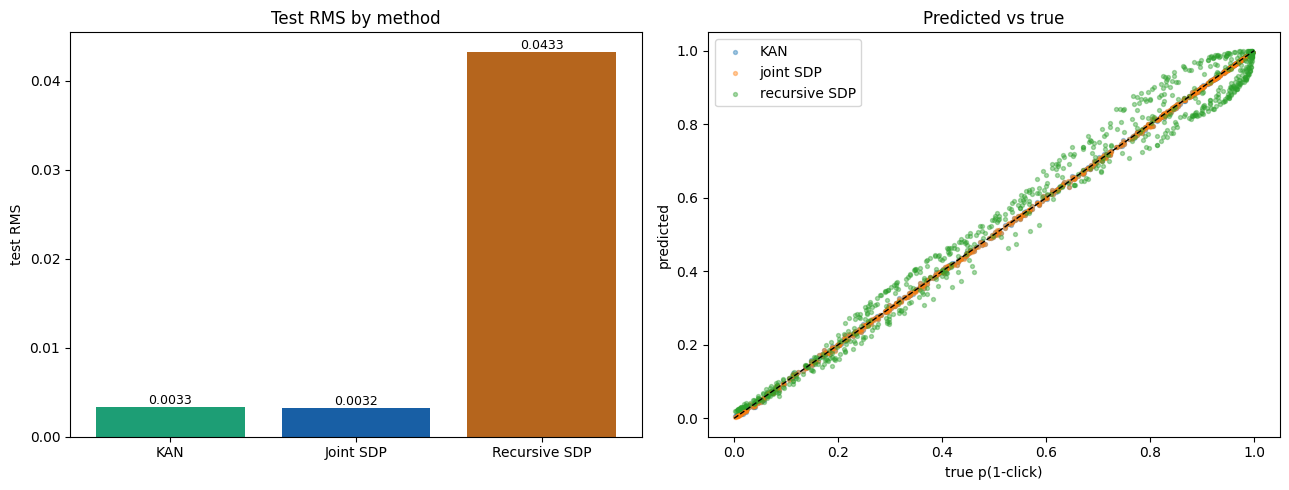

In [18]:
print("="*48)
print("  MOESM4  —  identical held-out test set")
print("="*48)
print("  KAN            test RMS : %.5f" % rms_kan)
print("  Joint SDP      test RMS : %.5f" % rms_joint)
print("  Recursive SDP  test RMS : %.5f" % rms_rec)
print("  paper reported          : ~0.005 region")
print("="*48)

labels = ["KAN", "Joint SDP", "Recursive SDP"]
vals = [rms_kan, rms_joint, rms_rec]
fig, ax = plt.subplots(1,2, figsize=(13,5))
ax[0].bar(labels, vals, color=['#1D9E75','#185FA5','#B5651D'])
for i,v in enumerate(vals): ax[0].text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=9)
ax[0].set_ylabel("test RMS"); ax[0].set_title("Test RMS by method")
ax[1].scatter(yte, p_te_kan, s=8, alpha=.4, label="KAN")
ax[1].scatter(yte, pred_joint, s=8, alpha=.4, label="joint SDP")
ax[1].scatter(yte, pred_rec, s=8, alpha=.4, label="recursive SDP")
ax[1].plot([0,1],[0,1],'k--',lw=1); ax[1].legend()
ax[1].set_xlabel("true p(1-click)"); ax[1].set_ylabel("predicted"); ax[1].set_title("Predicted vs true")
plt.tight_layout(); plt.show()

## 6 · Reading the results

**KAN (overfitting).** The 60/20/20 split lets the validation curve flag overfitting independently of the test set; the grid is chosen at the validation minimum. The reported test number is on data untouched by fitting or model selection. Grid refinement is the main accuracy lever.

**Two SDPs — the tradeoff.**
- **Joint** fits best on this small APD (~0.003 RMS, paper's ~0.005 region) because it uses the full 2-D statistics under one PSD constraint.
- **Recursive** is the paper's literal algorithm and yields a valid POVM, but fits less precisely here (~0.08 RMS). The phase-averaging discards information and the sequential per-band positivity compounds approximation error.
- **Why the paper uses recursion anyway:** it drops the cost per step from quadratic to linear in $d$, which is what makes the 1.8-million-parameter PNRD ($d=450$) tractable. On a small APD where the joint solve is feasible, joint wins on accuracy; the recursion's advantage is *scalability*, not precision. This accuracy ↔ tractability tradeoff is the key methodological point.

**The KAN's place.** It matches/approaches the joint SDP with no physics — no positivity, no Born rule, no operator — using only two inputs. Its cost is interpretability, which motivates symbolic extraction next.

### Implementation notes (recursive SDP)
- Reduced-function constant verified by forward Born-rule construction (coefficient ratio = 1.0 for all $l$).
- Positivity enforces **both** $M\succeq0$ and $I-M\succeq0$ on the **full** dimension $D$ at each step. Omitting the ceiling, or windowing the constraint, leaves the high-Fock region unconstrained and produces eigenvalues > 1 (invalid POVM).
- Truncation $D=58$ chosen from the leakage check; gridded data gives clean phase-averaging.
- Off-diagonals truncated at $L=4$ (paper: higher bands negligible, $l\ll d$).



In [19]:
# =============================================================================
#  RECURSIVE SDP — faithful to Zhang et al. 2012, SI §II
#  Drop-in replacement for MOESM4 cells 20 (setup), 22, 24, 26.
#  Assumes X, y, GAMMA, gammaln already defined as in your notebook.
#
#  WHAT CHANGED vs your previous version, and WHY:
#  (1) F_matrix is log-stabilised so the cosmetic divide-by-zero / overflow
#      warnings disappear (they did NOT affect numbers, but they hide real ones).
#  (2) Per-step DIAGNOSTICS: after each l we report the residual of THAT band's
#      reduced-function fit. This is how you see *which* step injects the error,
#      instead of only seeing the final 0.078.
#  (3) The l=0 diagonal fit is checked against the data directly (phase-averaged
#      Born prediction vs measured P^(0)) BEFORE moving on — the paper's whole
#      recursion rests on the diagonal being right first.
#  (4) Positivity follows the paper: start from the positive diagonal, ADD each
#      successive off-diagonal, enforcing the FULL operator >= 0 and I-op >= 0 at
#      each step (the rigorous multi-band form of the SI's Sylvester criterion).
# =============================================================================
import numpy as np
import cvxpy as cp
from scipy.special import gammaln

# ---- config (paper-faithful) -------------------------------------------------
D     = 58      # truncation; leakage-checked for |a|^2 up to ~38
L     = 4       # leading off-diagonals (paper: higher bands negligible, l << d)
GAMMA = 0.5     # paper's regulariser value
logfac = gammaln(np.arange(D + 5) + 1)

# ---- reduced (transformed-Husimi) functions, SI Eq. 1 ------------------------
keys = np.round(X[:, 0], 4)
phA  = X[:, 1]
uniq = np.unique(keys)

def reduced_P(l):
    """Phase-average measured p1 against e^{-il theta}, per brightness level."""
    mags = np.array([np.sqrt(k) for k in uniq])
    vals = np.array([np.mean(y[keys == k] * np.exp(-1j * l * phA[keys == k]))
                     for k in uniq])
    return mags, vals

def F_matrix(mags, l):
    """Design matrix: rows = brightness levels, cols = diagonal index j.
       F[i,j] = e^{-|a|^2} |a|^{2j+l} / sqrt((j+l)! j!).  Log-stabilised."""
    mags = np.asarray(mags, float)
    a2v  = mags ** 2
    n    = D - l
    F    = np.zeros((len(mags), n))
    nz   = mags > 0
    lm   = np.zeros_like(mags)
    lm[nz] = np.log(mags[nz])
    for j in range(n):
        logF = -a2v + (2 * j + l) * lm - 0.5 * (logfac[j + l] + logfac[j])
        F[:, j] = np.where(nz, np.exp(np.clip(logF, -700, 700)), 0.0)
    return F

# =============================================================================
#  STEP l = 0  — the diagonal.  Everything downstream depends on this.
# =============================================================================
m0, P0 = reduced_P(0)
F0 = F_matrix(m0, 0)
assert np.abs(P0.imag).max() < 1e-9, "P^(0) should be real"

d0 = cp.Variable(D)
prob0 = cp.Problem(
    cp.Minimize(cp.sum_squares(F0 @ d0 - P0.real) + GAMMA * cp.sum_squares(d0[1:] - d0[:-1])),
    [d0 >= 0, d0 <= 1])
prob0.solve(solver=cp.CLARABEL)
diag = np.array(d0.value)

# --- diagnostic: how well does the diagonal reproduce the l=0 reduced data? ---
resid0 = np.sqrt(np.mean((F0 @ diag - P0.real) ** 2))
print("="*64)
print("STEP l=0 (diagonal)")
print("  rises %.3f -> %.3f  (max %.3f)" % (diag[0], diag[min(40, D-1)], diag.max()))
print("  reduced-fn fit RMS : %.5f" % resid0)
print("  ^ if this is large, the recursion is doomed before any off-diagonal.")
print("="*64)

# =============================================================================
#  STEPS l = 1 .. L  — add each off-diagonal, full positivity at each step.
# =============================================================================
bands = {0: diag}
I = np.eye(D)
for l in range(1, L + 1):
    mL, PL = reduced_P(l)
    FL = F_matrix(mL, l)
    n  = D - l

    # imag-part sanity: for LO phase = 0 the bands are real; flag if not.
    im_ratio = np.abs(PL.imag).max() / (np.abs(PL.real).max() + 1e-12)
    flag = "  [warn imag/real=%.2f -> discarding signal]" % im_ratio if im_ratio > 0.1 else ""

    x = cp.Variable(n)
    M = cp.Constant(np.diag(diag))                       # fixed diagonal
    for ll in range(1, l):                               # fixed lower bands
        bv = bands[ll]
        M = M + cp.Constant(np.diag(bv, ll) + np.diag(bv, -ll))
    for j in range(n):                                   # variable band l
        S = np.zeros((D, D)); S[j, j+l] = 1; S[j+l, j] = 1
        M = M + x[j] * cp.Constant(S)

    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(FL @ x - PL.real) + GAMMA * cp.sum_squares(x[1:] - x[:-1])),
        [M >> 0, I - M >> 0])
    prob.solve(solver=cp.CLARABEL)
    bands[l] = np.array(x.value)

    resid = np.sqrt(np.mean((FL @ bands[l] - PL.real) ** 2))
    print("STEP l=%d | max|off| %.3f | reduced-fn fit RMS %.5f%s"
          % (l, np.abs(bands[l]).max(), resid, flag))

# ---- assemble Pi1 ------------------------------------------------------------
Pi1_rec = np.diag(diag)
for l in range(1, L + 1):
    bv = bands[l]
    for j in range(D - l):
        Pi1_rec[j, j+l] = bv[j]
        Pi1_rec[j+l, j] = bv[j]

ev = np.linalg.eigvalsh(Pi1_rec)
print("="*64)
print("recursive Pi1: eig [%.4f, %.4f]  valid POVM: %s"
      % (ev.min(), ev.max(), (ev.min() > -1e-3 and ev.max() < 1 + 1e-3)))
print("="*64)


STEP l=0 (diagonal)
  rises 0.121 -> 0.998  (max 0.999)
  reduced-fn fit RMS : 0.00514
  ^ if this is large, the recursion is doomed before any off-diagonal.
STEP l=1 | max|off| 0.166 | reduced-fn fit RMS 0.01902  [warn imag/real=0.42 -> discarding signal]
STEP l=2 | max|off| 0.091 | reduced-fn fit RMS 0.02313  [warn imag/real=0.78 -> discarding signal]
STEP l=3 | max|off| 0.078 | reduced-fn fit RMS 0.02410  [warn imag/real=0.80 -> discarding signal]
STEP l=4 | max|off| 0.026 | reduced-fn fit RMS 0.02206  [warn imag/real=0.86 -> discarding signal]
recursive Pi1: eig [0.0136, 1.0000]  valid POVM: True


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_1888/3628383973.py:71: RuntimeWarning: divide by zero encountered in matmul
  resid0 = np.sqrt(np.mean((F0 @ diag - P0.real) ** 2))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_1888/3628383973.py:71: RuntimeWarning: overflow encountered in matmul
  resid0 = np.sqrt(np.mean((F0 @ diag - P0.real) ** 2))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_1888/3628383973.py:71: RuntimeWarning: invalid value encountered in matmul
  resid0 = np.sqrt(np.mean((F0 @ diag - P0.real) ** 2))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_1888/3628383973.py:108: RuntimeWarning: divide by zero encountered in matmul
  resid = np.sqrt(np.mean((FL @ bands[l] - PL.real) ** 2))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_1888/3628383973.py:108: RuntimeWarning: overflow encountered in matmul
  resid = np.sqrt(np.mean((FL @ bands[l] - PL.real) ** 2))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/i